## To Plot Result Graphs on Benchmark CSV

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import os

In [21]:
# %% [markdown]
# # Poisson Image Editing Benchmark Visualization
# 
# This notebook plots performance metrics using appropriate chart types:
# - Bar charts for categorical comparisons (solvers, grid sizes, tile sizes)
# - Line graphs for scaling trends (core count scaling, problem size scaling)

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# CONSISTENT COOL/MUTED COLOR SCHEME
# ============================================================

# Solver colors - ORDERED: Equ, Grid, Brb, Msrb
solver_colors = {
    'EquSolver': '#4A6FA5',    # Muted steel blue (baseline)
    'GridSolver': '#6B8DB5',   # Soft blue-grey
    'BrbSolver': '#89A9C9',    # Pale blue
    'MsrbSolver': '#A8C4E0'    # Light powder blue (most advanced)
}

# Core colors - gradient of cool teals
core_colors = {
    1: '#2C5F6D',      # Deep teal
    2: '#3A7B8A',      # Medium teal
    4: '#4A97A8',      # Lighter teal
    8: '#5CB3C6'       # Soft teal
}

# Problem size colors - gradient from light to dark blue
size_colors = {
    '4.4K': '#B3D4E6',   # Very light blue
    '17K': '#8CB8D4',    # Light blue
    '66K': '#66A0C2',    # Medium-light blue
    '262K': '#4A86A8',   # Medium blue
    '1.1M': '#2E6B8A'    # Dark blue
}

# Grid size colors for bar charts (Slate Blues)
grid_size_colors = {
    '16x16': '#5C7A9E',
    '32x32': '#6D8BAB',
    '64x64': '#7F9CB8',
    '128x128': '#91ADC5',
    '256x256': '#A3BED2'
}

# Tile size colors for bar charts (Seafoam/Sage)
tile_size_colors = {
    16: '#4A8A8A',
    32: '#5C9A9A',
    64: '#6EAAAA',
    128: '#80BABA',
    256: '#92CACA'
}


# Define solver order for consistent plotting
SOLVER_ORDER = ['EquSolver', 'GridSolver', 'BrbSolver', 'MsrbSolver']

# ============================================================
# PLOT STYLE CONFIGURATION
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#F0F4F8'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

Path('plots').mkdir(parents=True, exist_ok=True)

# %% [code]
# Load the CSV results
csv_path = "results/benchmark_results.csv"
df = pd.read_csv(csv_path)

# Clean and prepare data
numeric_cols = ['pixels', 'cores', 'time_seconds','tile_size', 'actual_iterations', 'n_vars', 'tpo_ns', 'cmpo', 'cache_misses', 'cache_references']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter out invalid rows
df = df.dropna(subset=['tpo_ns', 'cmpo', 'cores', 'pixels'])
df = df[df['tpo_ns'] > 0]
df = df[df['cmpo'] > 0]

# Calculate cache miss rate
df['cache_miss_rate'] = df['cache_misses'] / df['cache_references'] * 100

# Round problem sizes for cleaner grouping
def round_pixels(p):
    if p >= 1000000:
        return 1052676
    elif p >= 260000:
        return 264196
    elif p >= 66000:
        return 66564
    elif p >= 16000:
        return 16900
    elif p >= 4000:
        return 4356
    else:
        return p

df['pixels_rounded'] = df['pixels'].apply(round_pixels)

# Add readable size labels
def size_label(p):
    if p >= 1052676:
        return '1.1M'
    elif p >= 264196:
        return '262K'
    elif p >= 66564:
        return '66K'
    elif p >= 16900:
        return '17K'
    elif p >= 4356:
        return '4.4K'
    else:
        return str(p)

df['size_label'] = df['pixels_rounded'].apply(size_label)
df['grid_label'] = df['grid_x'].astype(str) + 'x' + df['grid_y'].astype(str)

print(f"Loaded {len(df)} valid benchmark entries")
print(f"Solvers: {df['solver'].unique()}")
print(f"Cores: {sorted(df['cores'].unique())}")

Loaded 1640 valid benchmark entries
Solvers: ['EquSolver' 'GridSolver' 'BrbSolver' 'MsrbSolver']
Cores: [1, 2, 4, 8]


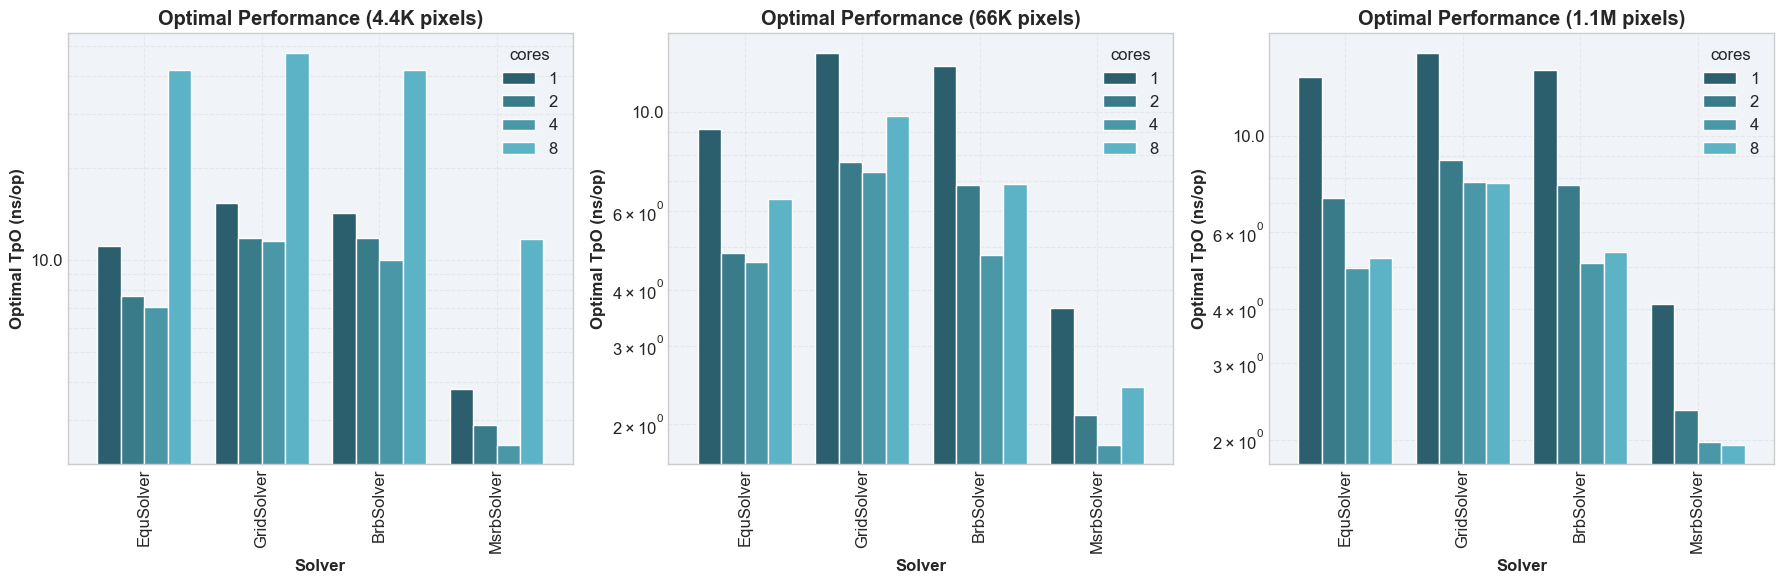

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, pixels in enumerate(problem_sizes):
    ax = axes[idx]
    
    # Filter and find optimal configuration
    subset = df[df['pixels'] == pixels]
    pivot = subset.pivot_table(
        index='solver', 
        columns='cores', 
        values='tpo_ns', 
        aggfunc='min'
    ).reindex(SOLVER_ORDER)
    
    # Plotting
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
               color=[core_colors.get(c, '#888888') for c in pivot.columns])
    
    # --- Y-Axis Tick Customization ---
    ax.set_yscale('log')
    
    # Increase number of major ticks
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=12))
    
    # Add minor ticks (the lines between 10, 100, 1000, etc.)
    # 'subs' defines the multiples (2, 3, 4...) to show ticks for
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=12))
    
    # Use ScalarFormatter to show actual numbers (e.g., 100) instead of powers (10^2)
    # only if the range isn't too extreme
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    ax.set_xlabel('Solver', fontweight='bold')
    ax.set_ylabel('Optimal TpO (ns/op)', fontweight='bold')
    ax.set_title(f'Optimal Performance ({size_labels_dict[pixels]})', fontweight='bold')
    ax.grid(True, which="both", alpha=0.3, axis='y') # Use which="both" to show minor grid lines

plt.tight_layout()
plt.savefig('plots/tpo_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()

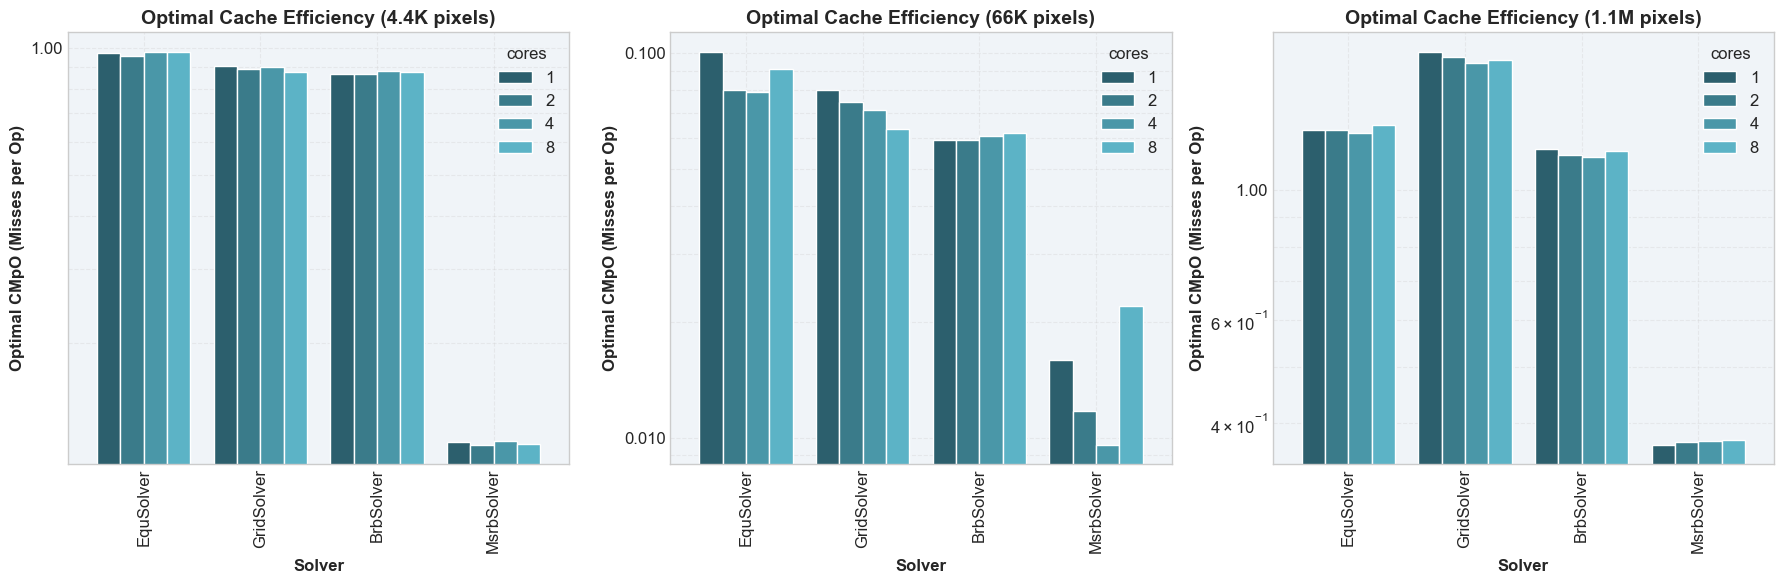

In [23]:
# 2. Pre-process: Ensure cmpo is numeric (benchmarks might output '-' for missing data)
df['cmpo'] = pd.to_numeric(df['cmpo'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, pixels in enumerate(problem_sizes):
    ax = axes[idx]
    
    # Filter for image size
    subset = df[df['pixels'] == pixels]
    
    # Select the optimal configuration (MINIMUM cache misses) for each solver/core pair
    pivot = subset.pivot_table(
        index='solver', 
        columns='cores', 
        values='cmpo', 
        aggfunc='min'
    ).reindex(SOLVER_ORDER)
    
    # Plotting
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
               color=[core_colors.get(c, '#888888') for c in pivot.columns])
    
    # --- Y-Axis Customization (Log Scale + Detailed Ticks) ---
    ax.set_yscale('log')
    
    # Force more major ticks and enable minor ticks (the lines between powers of 10)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=15))
    
    # Use standard numbers (0.1, 1, 10) instead of scientific notation
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    ax.set_xlabel('Solver', fontweight='bold', fontsize=12)
    ax.set_ylabel('Optimal CMpO (Misses per Op)', fontweight='bold', fontsize=12)
    ax.set_title(f'Optimal Cache Efficiency ({size_labels_dict[pixels]})', fontweight='bold', fontsize=14)
    
    # Grid on both major and minor ticks for readability
    ax.grid(True, which="both", alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/cmpo_bar_chart_optimal.png', dpi=200, bbox_inches='tight')
plt.show()

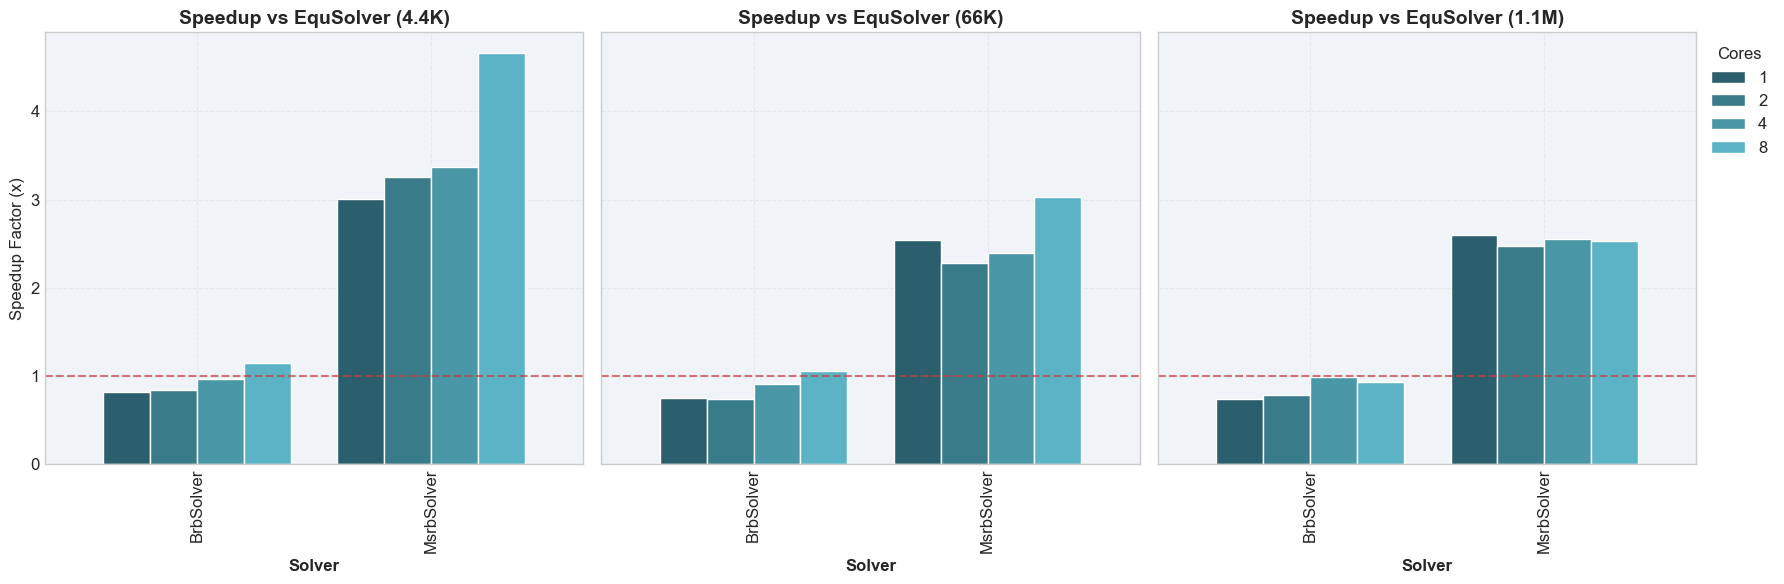

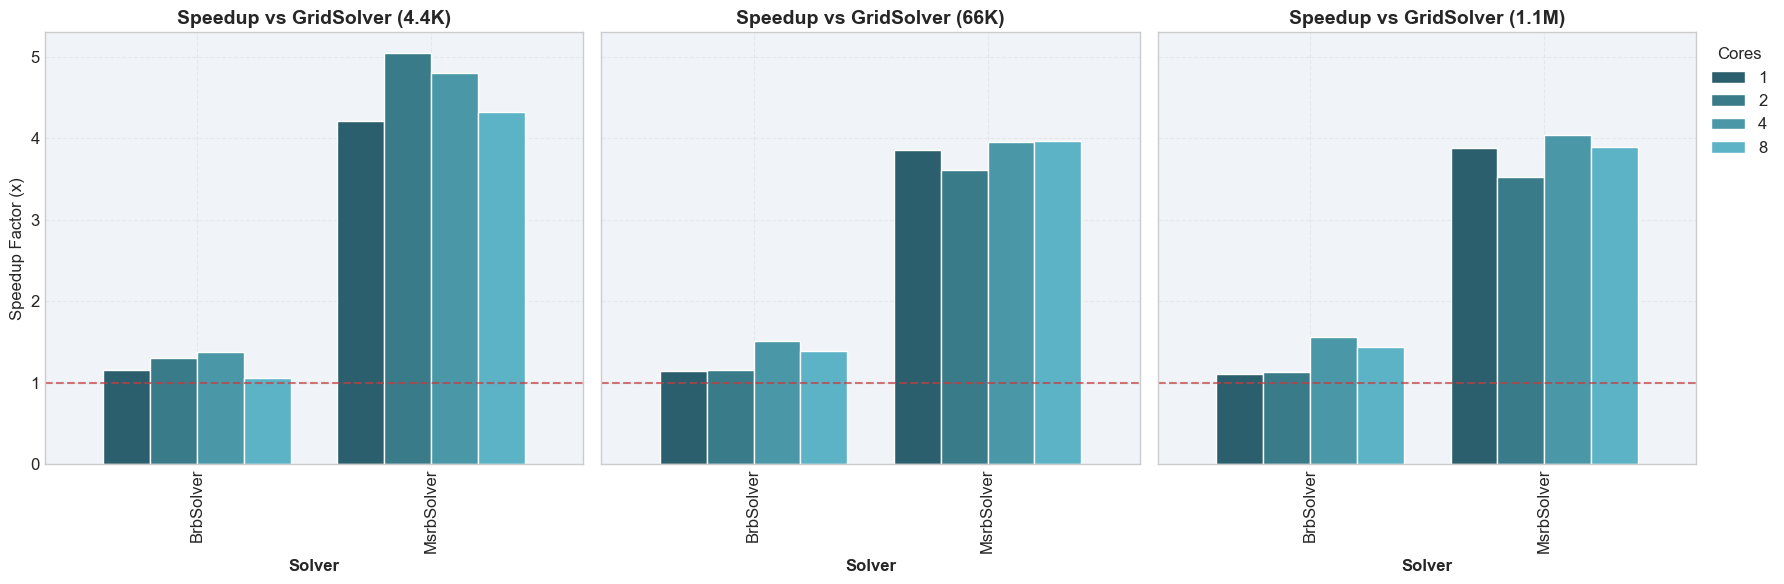

In [26]:
# ============================================================
# SPEEDUP VS BASELINES (OPTIMAL CONFIGS ONLY)
# ============================================================

# 1. Identify the optimal (minimum) TpO for each (solver, cores, pixels_rounded)
# This ensures we compare the best tile/grid size for each algorithm.
opt_pivot = df.groupby(['solver', 'cores', 'pixels_rounded'])['tpo_ns'].min().unstack('solver')

# 2. Calculate Speedup Metrics for Brb and Msrb
speedup_df = pd.DataFrame(index=opt_pivot.index)
speedup_df['Brb vs Equ']  = opt_pivot['EquSolver']  / opt_pivot['BrbSolver']
speedup_df['Msrb vs Equ'] = opt_pivot['EquSolver']  / opt_pivot['MsrbSolver']
speedup_df['Brb vs Grid'] = opt_pivot['GridSolver'] / opt_pivot['BrbSolver']
speedup_df['Msrb vs Grid'] = opt_pivot['GridSolver'] / opt_pivot['MsrbSolver']

# Specific problem sizes for the comparison
plot_sizes = [4356, 66564, 1052676]

# --- PLOT 1: SPEEDUP VS EQUSOLVER ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for idx, pixels in enumerate(plot_sizes):
    ax = axes[idx]
    size_str = size_label(pixels)
    
    # Extract data for this size: Index=Cores, Columns=Comparisons
    data = speedup_df.xs(pixels, level='pixels_rounded')[['Brb vs Equ', 'Msrb vs Equ']]
    
    # Plot: Transpose so Solvers are on X-axis, Cores are the color/bars
    data.T.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
                color=[core_colors.get(c) for c in data.index])
    
    ax.set_title(f'Speedup vs EquSolver ({size_str})', fontweight='bold', fontsize=14)
    ax.set_ylabel('Speedup Factor (x)' if idx == 0 else "")
    ax.set_xlabel('Solver', fontweight='bold')
    ax.set_xticklabels(['BrbSolver', 'MsrbSolver'], rotation=90)
    
    # Reference line at 1.0 (Baseline parity)
    ax.axhline(1.0, color='#C43D3D', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.grid(True, axis='y', alpha=0.3)
    
    if idx == 2:
        ax.legend(title='Cores', loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('plots/speedup_vs_equsolver.png', dpi=200, bbox_inches='tight')
plt.show()


# --- PLOT 2: SPEEDUP VS GRIDSOLVER ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for idx, pixels in enumerate(plot_sizes):
    ax = axes[idx]
    size_str = size_label(pixels)
    
    data = speedup_df.xs(pixels, level='pixels_rounded')[['Brb vs Grid', 'Msrb vs Grid']]
    
    data.T.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
                color=[core_colors.get(c) for c in data.index])
    
    ax.set_title(f'Speedup vs GridSolver ({size_str})', fontweight='bold', fontsize=14)
    ax.set_ylabel('Speedup Factor (x)' if idx == 0 else "")
    ax.set_xlabel('Solver', fontweight='bold')
    ax.set_xticklabels(['BrbSolver', 'MsrbSolver'], rotation=90)
    
    ax.axhline(1.0, color='#C43D3D', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.grid(True, axis='y', alpha=0.3)
    
    if idx == 2:
        ax.legend(title='Cores', loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('plots/speedup_vs_gridsolver.png', dpi=200, bbox_inches='tight')
plt.show()

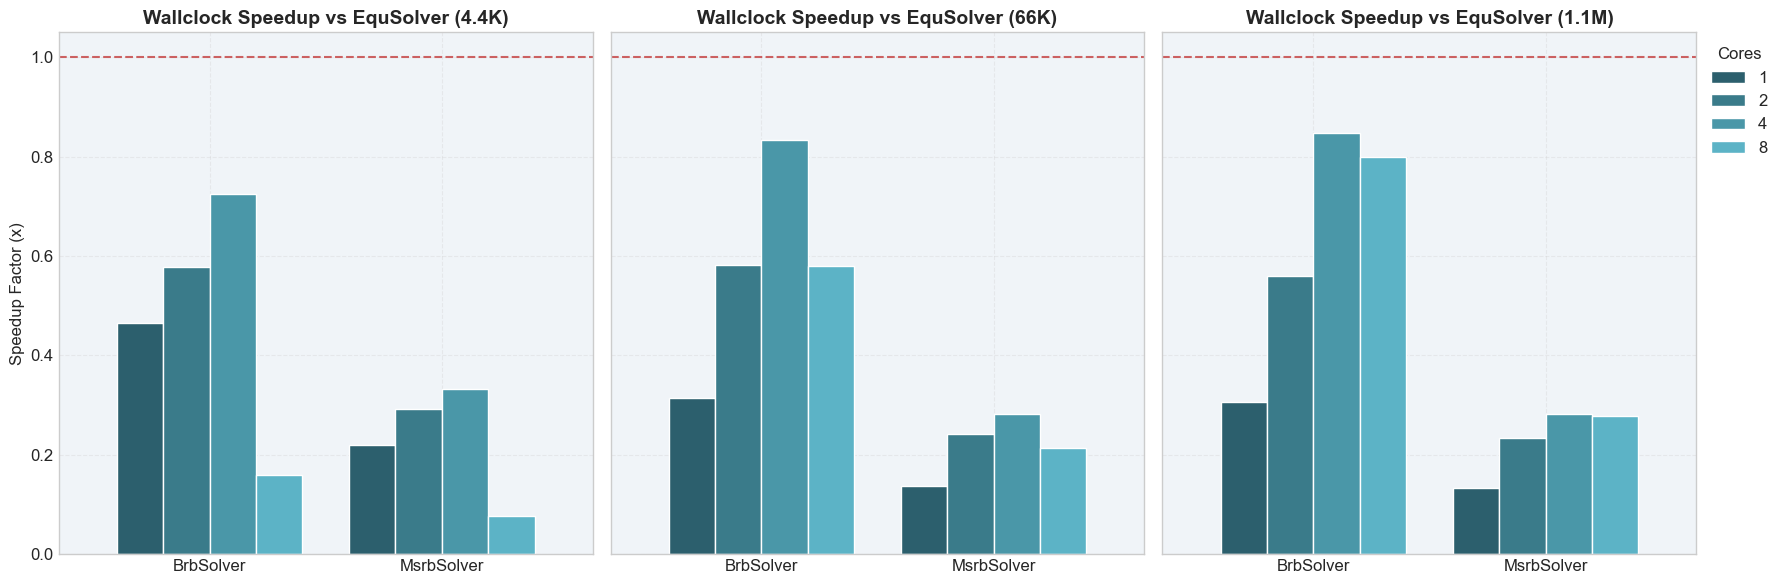

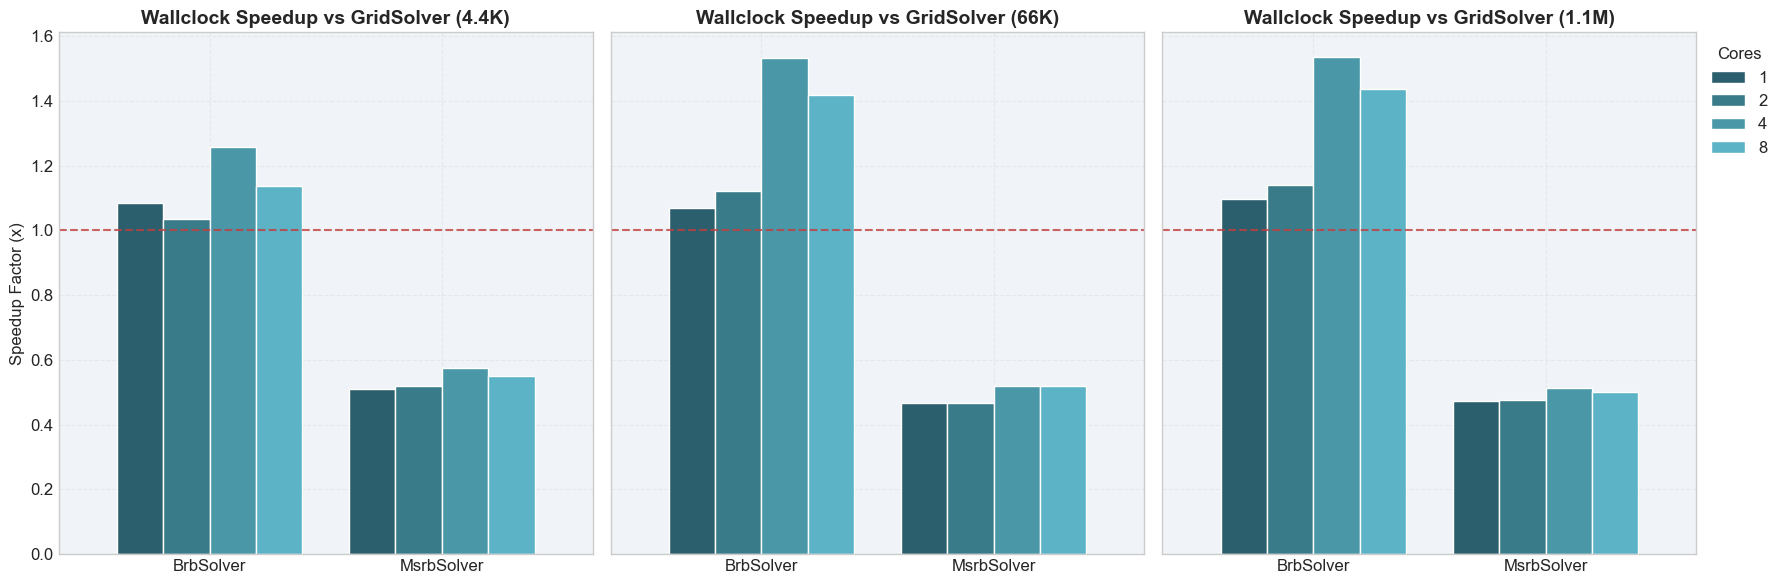

In [28]:
# %% [code]
# 1. Identify optimal (minimum) wallclock time for each configuration
opt_time = df.groupby(['solver', 'cores', 'pixels_rounded'])['time_seconds'].min().unstack('solver')

# 2. Select the specific problem sizes requested
target_sizes = [4356, 66564, 1052676]

# --- PLOT 1: Wallclock Speedup vs EquSolver ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, pixels in enumerate(target_sizes):
    ax = axes[i]
    label = size_label(pixels)
    
    # Baseline: EquSolver (Sequential time for this size)
    equ_baseline = opt_time.xs(pixels, level='pixels_rounded')['EquSolver'].min()
    
    # Calculate speedup relative to EquSolver
    subset = opt_time.xs(pixels, level='pixels_rounded')
    data = pd.DataFrame({
        'BrbSolver': equ_baseline / subset['BrbSolver'],
        'MsrbSolver': equ_baseline / subset['MsrbSolver']
    })
    
    # Plot using core_colors for the bars
    data.T.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
                color=[core_colors.get(c) for c in data.index])
    
    ax.set_title(f'Wallclock Speedup vs EquSolver ({label})', fontweight='bold', fontsize=14)
    ax.set_ylabel('Speedup Factor (x)' if i == 0 else "")
    ax.set_xlabel('')
    ax.set_xticklabels(['BrbSolver', 'MsrbSolver'], rotation=0)
    ax.axhline(1.0, color='#C43D3D', linestyle='--', alpha=0.8)
    ax.grid(True, axis='y', alpha=0.3)
    
    if i == 2:
        ax.legend(title='Cores', loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('plots/wallclock_speedup_vs_equsolver.png', dpi=200, bbox_inches='tight')
plt.show()

# --- PLOT 2: Wallclock Speedup vs GridSolver ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, pixels in enumerate(target_sizes):
    ax = axes[i]
    label = size_label(pixels)
    
    # Baseline: GridSolver at matching core counts
    subset = opt_time.xs(pixels, level='pixels_rounded')
    data = pd.DataFrame({
        'BrbSolver': subset['GridSolver'] / subset['BrbSolver'],
        'MsrbSolver': subset['GridSolver'] / subset['MsrbSolver']
    })
    
    # Plot using core_colors for the bars
    data.T.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
                color=[core_colors.get(c) for c in data.index])
    
    ax.set_title(f'Wallclock Speedup vs GridSolver ({label})', fontweight='bold', fontsize=14)
    ax.set_ylabel('Speedup Factor (x)' if i == 0 else "")
    ax.set_xlabel('')
    ax.set_xticklabels(['BrbSolver', 'MsrbSolver'], rotation=0)
    ax.axhline(1.0, color='#C43D3D', linestyle='--', alpha=0.8)
    ax.grid(True, axis='y', alpha=0.3)
    
    if i == 2:
        ax.legend(title='Cores', loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('plots/wallclock_speedup_vs_gridsolver.png', dpi=200, bbox_inches='tight')
plt.show()

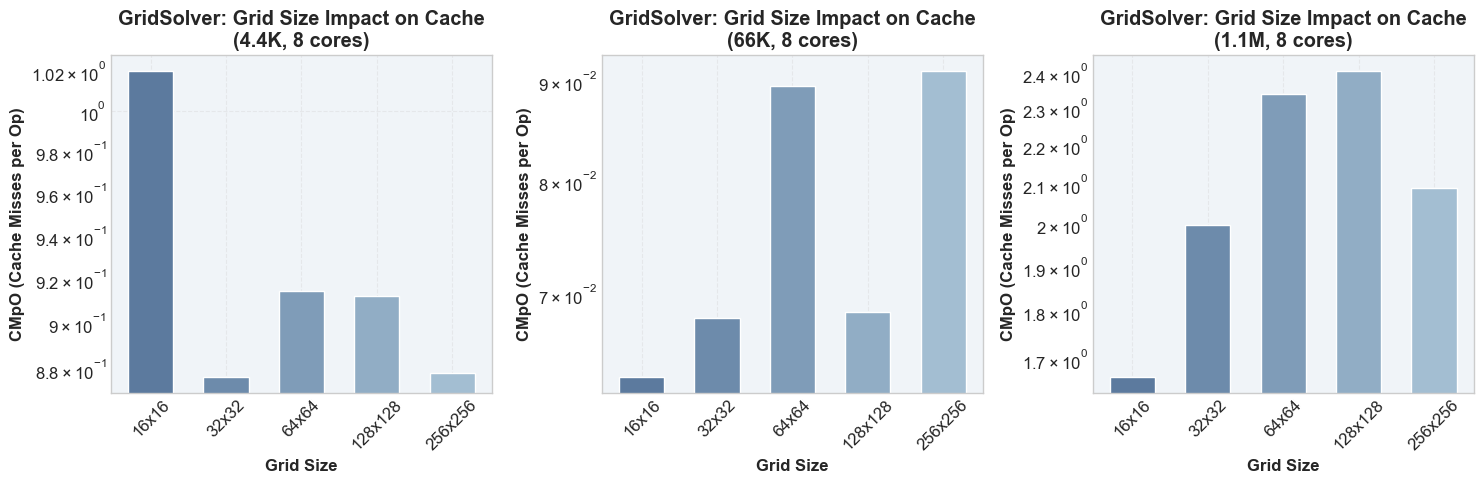

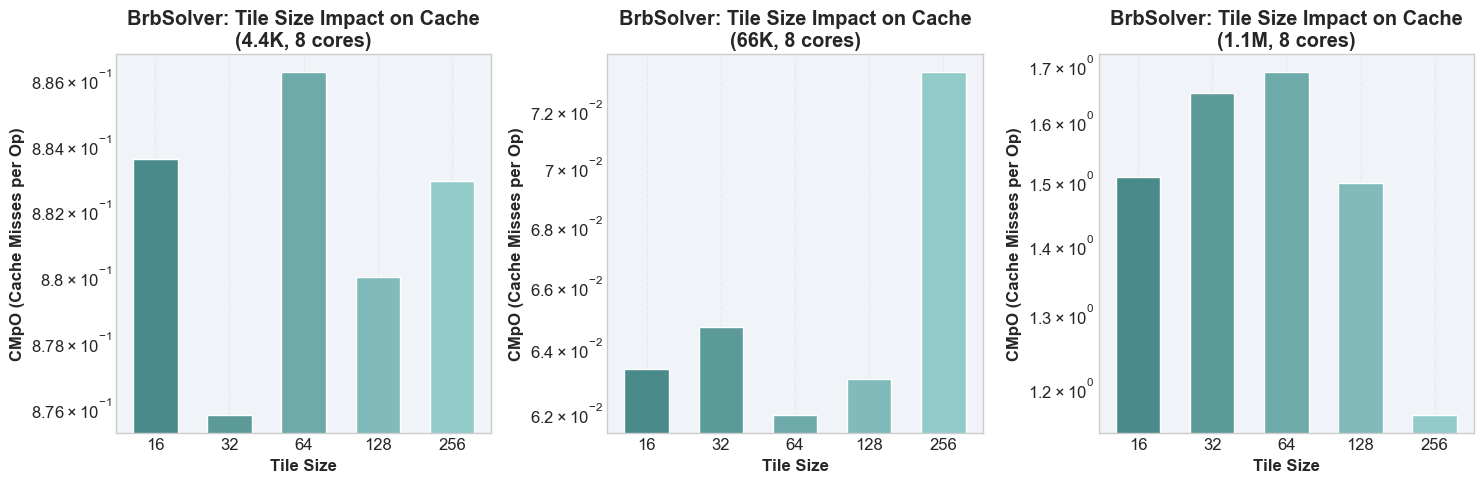

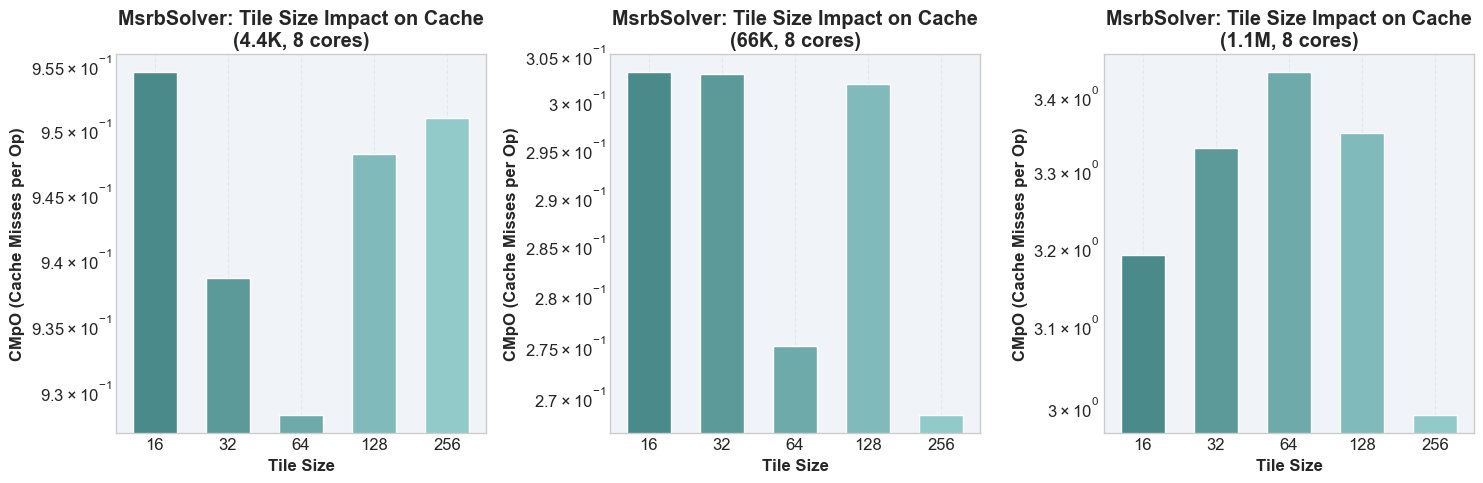

In [41]:
# %% [markdown]
# ## Grid Size Analysis - BAR CHART (CMpO for GridSolver)

# %% [code]
grid_df = df[df['solver'] == 'GridSolver']
grid_df = grid_df[grid_df['cores'] == 8]

if not grid_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    grid_order = ['16x16', '32x32', '64x64', '128x128', '256x256']
    
    for idx, pixels in enumerate(problem_sizes):
        ax = axes[idx]
        subset = grid_df[grid_df['pixels'] == pixels]
        
        # Prepare CMpO data
        grid_data = []
        for g in grid_order:
            val = subset[subset['grid_label'] == g]['cmpo'].values
            grid_data.append(val[0] if len(val) > 0 else 0)
        
        bars = ax.bar(grid_order, grid_data, width=0.6,
                      color=[grid_size_colors.get(g, '#888888') for g in grid_order],
                      edgecolor='white', linewidth=1)
        
        ax.set_xlabel('Grid Size', fontweight='bold')
        ax.set_ylabel('CMpO (Cache Misses per Op)', fontweight='bold')
        ax.set_title(f'GridSolver: Grid Size Impact on Cache\n({size_labels_dict[pixels]}, 8 cores)', fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('plots/gridsolver_gridsize_cmpo_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ## Tile Size Analysis - BAR CHART (CMpO for BrbSolver & MsrbSolver)

# %% [code]
for solver_name in ['BrbSolver', 'MsrbSolver']:
    solver_df = df[df['solver'] == solver_name]
    solver_df = solver_df[solver_df['cores'] == 8]
    
    if not solver_df.empty:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        tile_order = [16, 32, 64, 128, 256]
        
        for idx, pixels in enumerate(problem_sizes):
            ax = axes[idx]
            subset = solver_df[solver_df['pixels'] == pixels]
            
            # Prepare CMpO data
            tile_data = []
            for t in tile_order:
                val = subset[subset['tile_size'] == t]['cmpo'].values
                tile_data.append(val[0] if len(val) > 0 else 0)
            
            bars = ax.bar([str(t) for t in tile_order], tile_data, width=0.6,
                          color=[tile_size_colors.get(t, '#888888') for t in tile_order],
                          edgecolor='white', linewidth=1)
            
            ax.set_xlabel('Tile Size', fontweight='bold')
            ax.set_ylabel('CMpO (Cache Misses per Op)', fontweight='bold')
            ax.set_title(f'{solver_name}: Tile Size Impact on Cache\n({size_labels_dict[pixels]}, 8 cores)', fontweight='bold')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(f'plots/{solver_name.lower()}_tilesize_cmpo_analysis.png', dpi=200, bbox_inches='tight')
        plt.show()

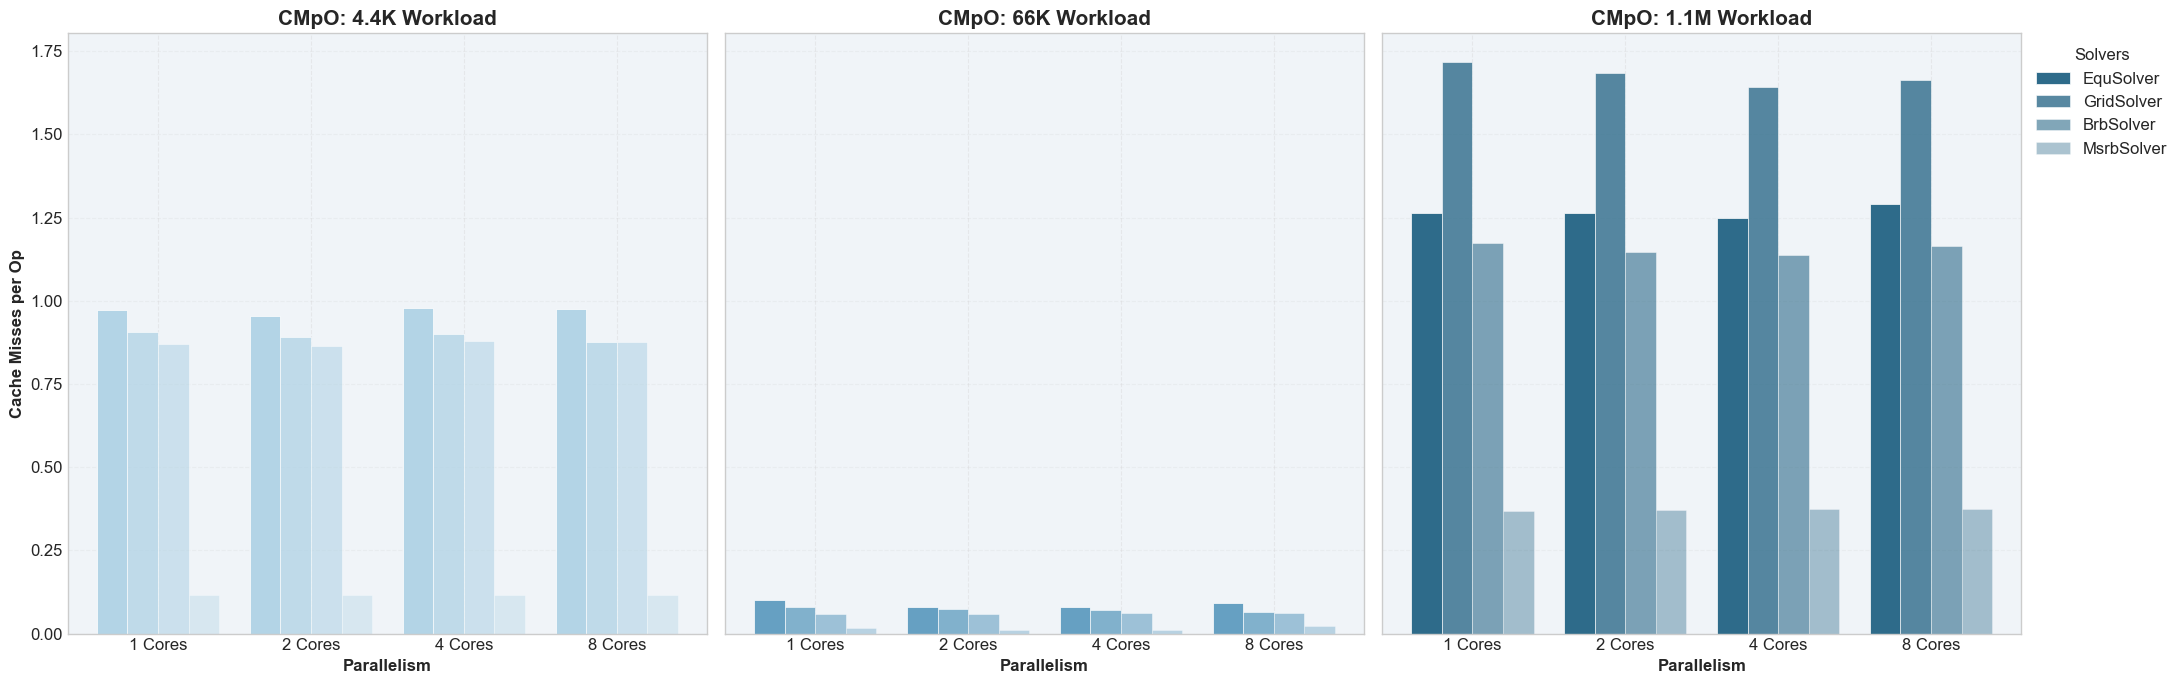

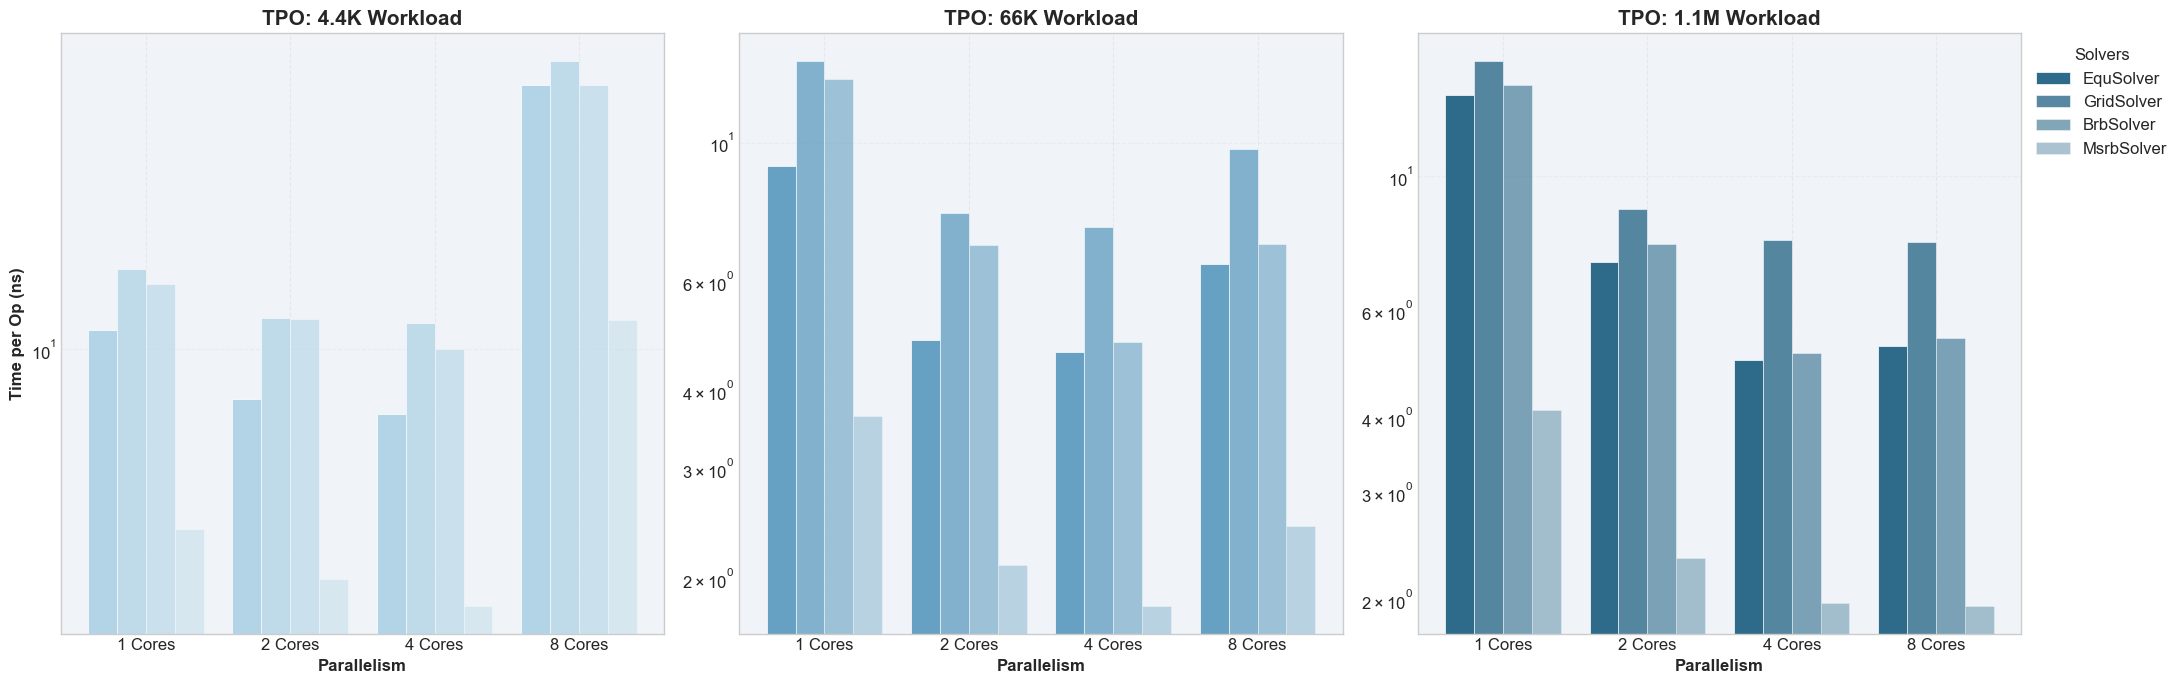

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess data
df = pd.read_csv('results/benchmark_results.csv')

# Pre-defined constants
problem_sizes = [4356, 66564, 1052676]
size_labels = {4356: '4.4K', 66564: '66K', 1052676: '1.1M'}
# Use your problem size colors as base themes
base_colors = {4356: '#B3D4E6', 66564: '#66A0C2', 1052676: '#2E6B8A'}

solvers = ['EquSolver', 'GridSolver', 'BrbSolver', 'MsrbSolver']
core_counts = [1, 2, 4, 8]

# Helper to generate shades for solvers within a theme
def get_solver_colors(base_hex):
    # Returns 4 variations of the base color to distinguish solvers
    return [base_hex, base_hex + 'CC', base_hex + '99', base_hex + '66'] # Simplified logic

# ==========================================
# PLOTTING CMpO & TPO (Grouped Bar Charts)
# ==========================================
for metric in ['cmpo', 'tpo_ns']:
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=(metric == 'cmpo'))
    
    ylabel = 'Cache Misses per Op' if metric == 'cmpo' else 'Time per Op (ns)'
    title_prefix = 'CMpO' if metric == 'cmpo' else 'TPO'

    for i, pixels in enumerate(problem_sizes):
        ax = axes[i]
        theme_color = base_colors[pixels]
        
        # Setup bar positions
        x = np.arange(len(core_counts))
        width = 0.2  # Width of individual solver bars
        
        for j, solver in enumerate(solvers):
            optimal_vals = []
            for c in core_counts:
                # Find min value (optimal configuration) for this solver/core/pixel combo
                subset = df[(df['solver'] == solver) & 
                            (df['cores'] == c) & 
                            (df['pixels'] == pixels)]
                
                if not subset.empty:
                    optimal_vals.append(subset[metric].min())
                else:
                    optimal_vals.append(0)
            
            # Position bars for each solver side-by-side
            offset = (j - 1.5) * width
            ax.bar(x + offset, optimal_vals, width, label=solver, 
                   color=theme_color, alpha=1.0 - (j * 0.2), # Differentiate by transparency
                   edgecolor='white', linewidth=0.5)

        # Formatting
        ax.set_title(f'{title_prefix}: {size_labels[pixels]} Workload', fontweight='bold', fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{c} Cores' for c in core_counts])
        ax.set_xlabel('Parallelism', fontweight='bold')
        
        if i == 0: ax.set_ylabel(ylabel, fontweight='bold')
        if metric == 'tpo_ns': ax.set_yscale('log') # Time scales exponentially
        
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if i == 2: ax.legend(title="Solvers", loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.savefig(f'plots/scaling_analysis_{metric}_bars.png', dpi=200)
    plt.show()

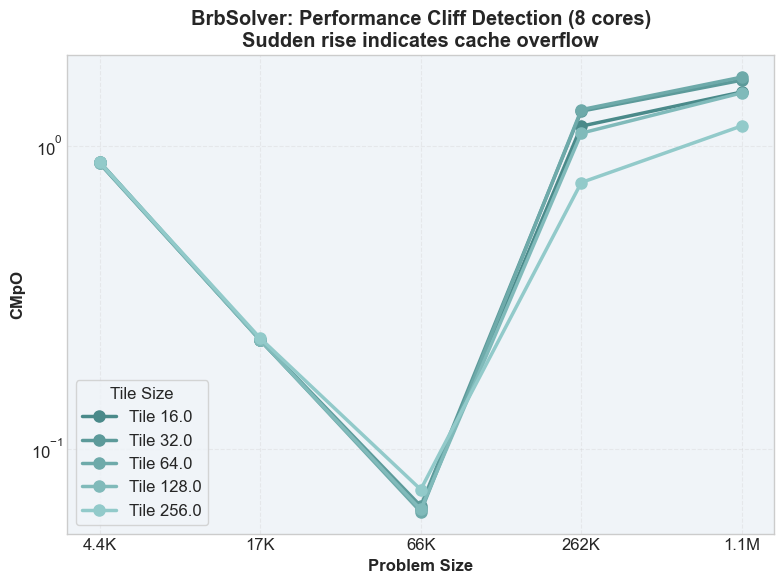

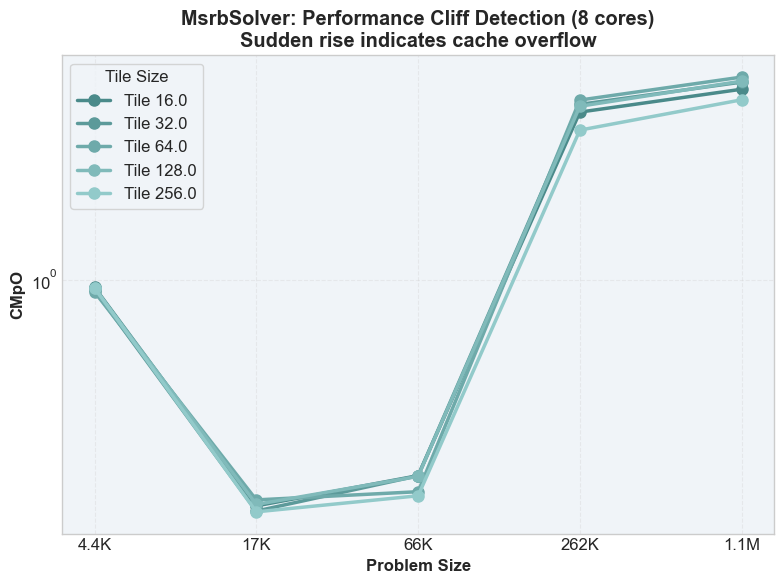

In [43]:
# ## 10. Performance Cliff Detection - Line Graph

for solver_name in ['BrbSolver', 'MsrbSolver']:
    solver_df = df[df['solver'] == solver_name]
    solver_df = solver_df[solver_df['cores'] == 8]
    
    if not solver_df.empty:
        fig, ax = plt.subplots(figsize=(8, 6))
        
        for tile in sorted(solver_df['tile_size'].unique()):
            subset = solver_df[solver_df['tile_size'] == tile]
            sizes = []
            cmpos = []
            for s in ['4.4K', '17K', '66K', '262K', '1.1M']:
                val = subset[subset['size_label'] == s]['cmpo'].values
                if len(val) > 0:
                    sizes.append(s)
                    cmpos.append(val[0])
            
            ax.plot(sizes, cmpos, 'o-', linewidth=2.5, markersize=8,
                   label=f'Tile {tile}', color=tile_size_colors.get(tile, '#888888'))
        
        ax.set_xlabel('Problem Size', fontweight='bold')
        ax.set_ylabel('CMpO', fontweight='bold')
        ax.set_title(f'{solver_name}: Performance Cliff Detection (8 cores)\nSudden rise indicates cache overflow', fontweight='bold')
        ax.set_yscale('log')
        ax.legend(title='Tile Size', frameon=True)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'plots/{solver_name.lower()}_performance_cliff_line.png', dpi=200, bbox_inches='tight')
        plt.show()